In [ ]:
# первый блок, ввод данных
# вариант 57


import numpy as np

X = np.array([72, 52, 73, 74, 76, 79, 54, 68, 73, 64])
Y = np.array([121, 84, 119, 117, 129, 128, 102, 111, 112, 98])

In [3]:
# второй блок, расчёт коэф корреляции
# вывод о силе и направлении
import matplotlib.pyplot as plt

# коэффициент корреляции Пирсона
r = np.corrcoef(X, Y)[0, 1]
print(f"Коэффициент корреляции Пирсона r = {r:.3f}")

Коэффициент корреляции Пирсона r = 0.913


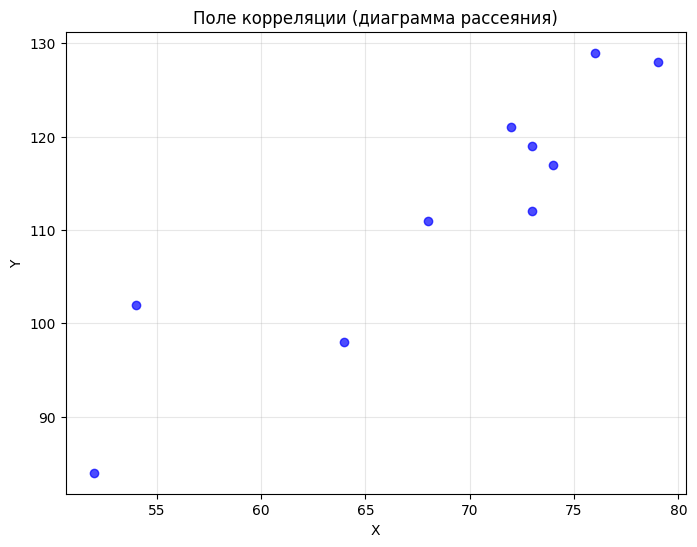

In [4]:
# третий блок, поле корреляции

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Поле корреляции (диаграмма рассеяния)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# четвёртый блок, вывод уравнения линейной регресии

X_mean, Y_mean = X.mean(), Y.mean() # сред знач переменных X Y
sx, sy = X.std(ddof=1), Y.std(ddof=1) # стандартные отклонения

a1 = r * sy / sx # коэф наклона лин рег a1
a0 = Y_mean - a1 * X_mean # своб член линейной модели(пересечение с осью Y)

print(f"Y = {a0:.3f} + {a1:.3f} X") # вывод уравнения лин рег

Y = 15.927 + 1.404 X


Прогнозные значения Ŷ:
X[0] = 72, Y_actual = 121, Ŷ[0] = 117.014
X[1] = 52, Y_actual = 84, Ŷ[1] = 88.934
X[2] = 73, Y_actual = 119, Ŷ[2] = 118.418
X[3] = 74, Y_actual = 117, Ŷ[3] = 119.822
X[4] = 76, Y_actual = 129, Ŷ[4] = 122.630
X[5] = 79, Y_actual = 128, Ŷ[5] = 126.842
X[6] = 54, Y_actual = 102, Ŷ[6] = 91.742
X[7] = 68, Y_actual = 111, Ŷ[7] = 111.398
X[8] = 73, Y_actual = 112, Ŷ[8] = 118.418
X[9] = 64, Y_actual = 98, Ŷ[9] = 105.782


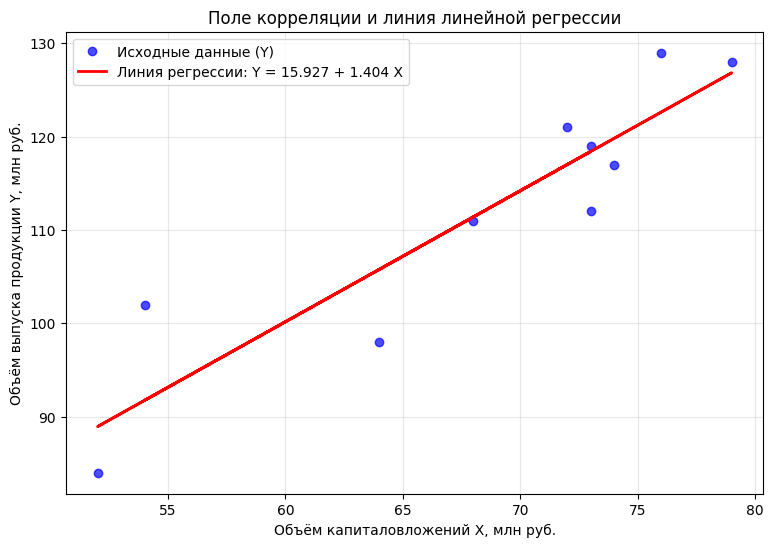

In [9]:
# пятый блок, прогнозы значения Y
# поле корреляции с линией регресии

# прогнозные значения Ŷ для КАЖДОГО значения Xj
Y_hat = a0 + a1 * X   # вектор (10,) прогнозов

print("Прогнозные значения Ŷ:")
for j in range(len(X)):
    print(f"X[{j}] = {X[j]}, Y_actual = {Y[j]}, Ŷ[{j}] = {Y_hat[j]:.3f}")

# новое поле корреляции + линия регрессии

plt.figure(figsize=(9, 6))

# 1) исходные точки (поле корреляции)
plt.scatter(X, Y, color='blue', alpha=0.7, label='Исходные данные (Y)')

# 2) линия регрессии: проводим её по X и построенным Ŷ
plt.plot(X, Y_hat, color='red', linewidth=2, label=f'Линия регрессии: Y = {a0:.3f} + {a1:.3f} X')

# 3) подписи осей и заголовок
plt.xlabel('Объём капиталовложений X, млн руб.')
plt.ylabel('Объём выпуска продукции Y, млн руб.')
plt.title('Поле корреляции и линия линейной регрессии')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [11]:
# шестой блок, стандартная ошибка регресии
# коэф детерминации
# какая доля вариации результирующего показателя объясняется с помощью уравнения регресии

n = len(X)

# остатки (факт минус прогноз)
residuals = Y - Y_hat

# сумма квадратов остатков
ssr = np.sum(residuals**2)

# среднеквадратическая ошибка (MSE)
mse = ssr / (n - 2)

# стандартная ошибка регрессии
s_yx = np.sqrt(mse)

print(f"Стандартная ошибка регрессии S_y/x = {s_yx:.3f}")

# способ 1 (проще, через r)
R2 = r**2
print(f"Коэффициент детерминации R^2 = {R2:.3f}")

# можно проверить вторым способом (опционально)
ss_tot = np.sum((Y - Y_mean)**2)
ss_res = np.sum(residuals**2)
R2_check = 1 - ss_res / ss_tot
print(f"R^2 (через суммы квадратов) = {R2_check:.3f}")

Стандартная ошибка регрессии S_y/x = 6.099
Коэффициент детерминации R^2 = 0.833
R^2 (через суммы квадратов) = 0.833


In [14]:
# седьмой блок, 
# коэффициенты регресии, другие показатели регресии

print(f"Y = {a0:.3f} + {a1:.3f} X") # коэф регресии уже были посчитаны в блоке 4

print(f"Стандартная ошибка регрессии S_y/x = {s_yx:.3f}") # показатели регресии уже были посчитаны в блоке 6
print(f"Коэффициент детерминации R^2 = {R2:.3f}") # показатели регресии уже были посчитаны в блоке 6

Y = 15.927 + 1.404 X
Стандартная ошибка регрессии S_y/x = 6.099
Коэффициент детерминации R^2 = 0.833


In [17]:
# восьмой блок
# проверка значимости параметров уравнения регресии
# с помощью t-критерия СТьюдента при уровне значимости a = 0.05

from scipy.stats import t

n = len(X)
s_yx = np.sqrt(mse)  # стандартная ошибка регрессии (уже посчитана)
sx = X.std(ddof=1)   # выборочное стандартное отклонение X
X_mean = X.mean()

# степень свободы
df = n - 2

# критическое значение t для уровня значимости 0.05 (двусторонний тест)
t_critical = t.ppf(1 - 0.05 / 2, df)
print(f"t_критическое (α=0.05, df={df}) = {t_critical:.3f}")

# стандартная ошибка коэффициента a1
se_a1 = s_yx / np.sqrt((n - 1) * sx**2)
t_a1 = a1 / se_a1

# стандартная ошибка коэффициента a0
se_a0 = s_yx * np.sqrt(1/n + X_mean**2/((n-1) * sx**2))
t_a0 = a0 / se_a0

print(f"t(a1) = {t_a1:.3f} (Коэффициент регрессии)")
print(f"t(a0) = {t_a0:.3f} (Свободный член)")

# вывод: значим ли коэффициент?
def is_significant(tt, tcrit, alpha=0.05):
    if abs(tt) > tcrit:
        print(f"t = {tt:.3f} > {tcrit:.3f} → коэффициент значим (p < {alpha})")
    else:
        print(f"t = {tt:.3f} ≤ {tcrit:.3f} → коэффициент НЕ значим (p ≥ {alpha})")

print("\nРезультаты проверки значимости:")
is_significant(t_a1, t_critical)  # обычно для a1 всегда важен
is_significant(t_a0, t_critical)

t_критическое (α=0.05, df=8) = 2.306
t(a1) = 6.315 (Коэффициент регрессии)
t(a0) = 1.037 (Свободный член)

Результаты проверки значимости:
t = 6.315 > 2.306 → коэффициент значим (p < 0.05)
t = 1.037 ≤ 2.306 → коэффициент НЕ значим (p ≥ 0.05)


In [19]:
# девятый блок
# проверить значимость уравнения регресии с помощью F - критерия Фишера(a = 0.05), найти среднюю ошибку аппроксимации


# повторный вывод R^2 (он уже посчитан в блоке 6)
print(f"Коэффициент детерминации R^2 = {R2:.3f}")

from scipy.stats import f

n = len(X)

# F-статистика для уравнения регрессии
R2 = r**2
F_stat = (R2 / (1 - R2)) * (n - 2)
print(f"F-статистика = {F_stat:.3f}")

# критическое значение F при alpha = 0.05, df1 = 1, df2 = n - 2
df1 = 1
df2 = n - 2
F_critical = f.ppf(1 - 0.05, df1, df2)
print(f"F_критическое (α=0.05, df1={df1}, df2={df2}) = {F_critical:.3f}")

if F_stat > F_critical:
    print("F > F_кр → уравнение регрессии значимо (p < 0.05)")
else:
    print("F ≤ F_кр → уравнение регрессии НЕ значимо (p ≥ 0.05)")

# средняя ошибка аппроксимации в процентах
relative_errors = np.abs((Y - Y_hat) / Y)
mean_approx_error = np.mean(relative_errors) * 100
print(f"Средняя ошибка аппроксимации = {mean_approx_error:.2f} %")

Коэффициент детерминации R^2 = 0.833
F-статистика = 39.876
F_критическое (α=0.05, df1=1, df2=8) = 5.318
F > F_кр → уравнение регрессии значимо (p < 0.05)
Средняя ошибка аппроксимации = 4.20 %
